
ANÁLISE DESCRITIVA DOS DATASETS

=== PROD_AGRICOLA ===
               Ano         Valor
count    69.000000  6.900000e+01
mean   2013.000000  1.309437e+08
std       6.681845  1.503467e+08
min    2002.000000  4.699400e+07
25%    2007.000000  5.905960e+07
50%    2013.000000  7.327434e+07
75%    2019.000000  9.165108e+07
max    2024.000000  7.163265e+08

=== PIB ===
              Ano  PIB-Milhões de Reais
count    23.00000          2.300000e+01
mean   2013.00000          5.466684e+06
std       6.78233          3.017963e+06
min    2002.00000          1.488787e+06
25%    2007.50000          2.915033e+06
50%    2013.00000          5.331619e+06
75%    2018.50000          7.195596e+06
max    2024.00000          1.174474e+07

ANÁLISE DE VALORES FALTANTES (dropna)

PROD_AGRICOLA:
  Linhas antes: 69
  Linhas após limpeza: 69
  Linhas removidas: 0
  Percentual removido: 0.00%

PIB:
  Linhas antes: 23
  Linhas após limpeza: 23
  Linhas removidas: 0
  Percentual removido: 0.00%

PREPARANDO DADOS PAR

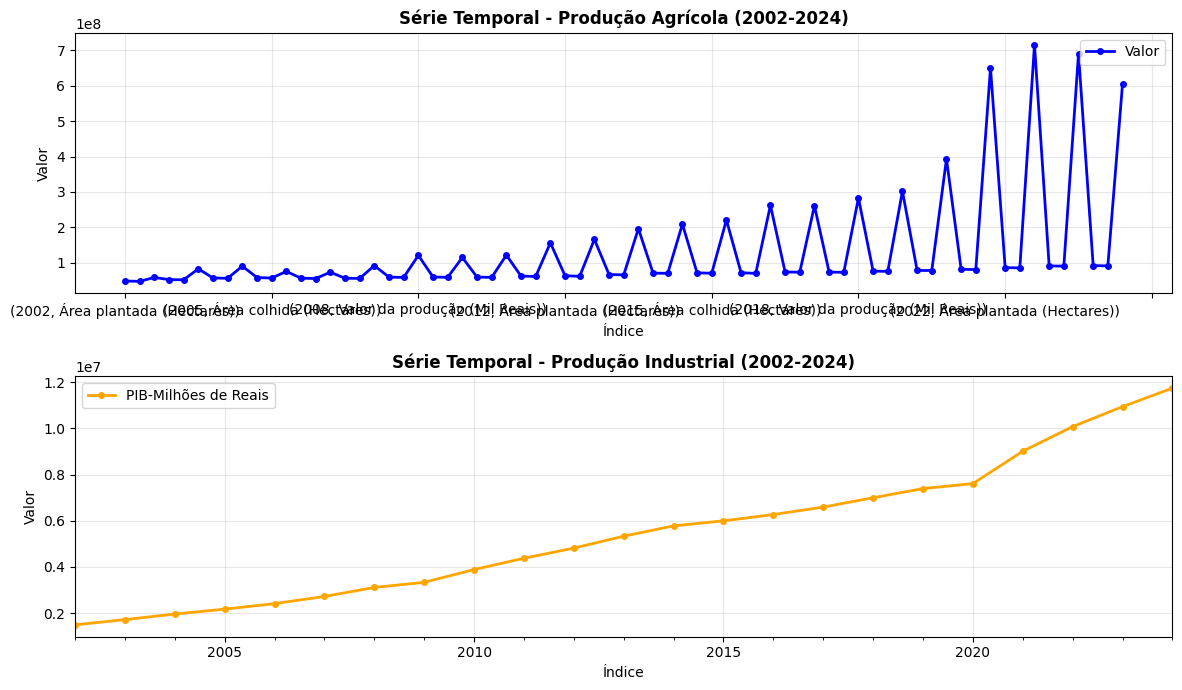


PLOTANDO HISTOGRAMAS


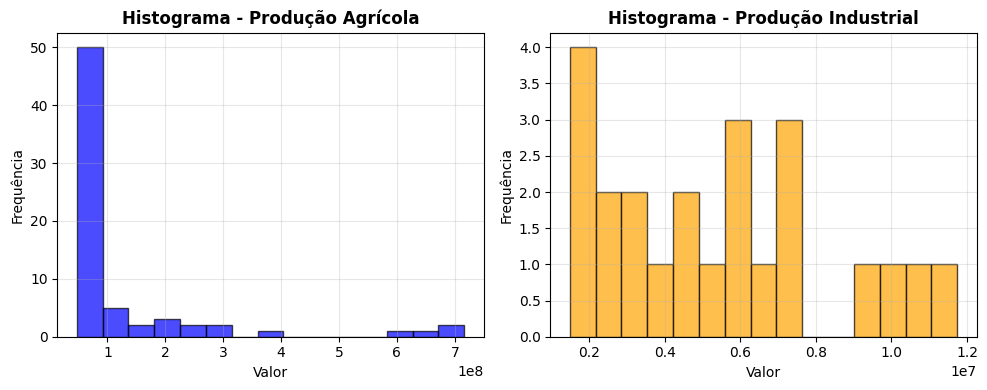

In [ ]:
from typing import Dict, Optional, List
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import traceback
import re
# ============================================================
# FUNÇÕES DE CARREGAMENTO E PRÉ-PROCESSAMENTO
# ============================================================

def load_data(file_paths: Dict[str, str]) -> Dict[str, pd.DataFrame]:
    """Carrega múltiplos arquivos CSV"""
    datasets: Dict[str, pd.DataFrame] = {}
    for name, path in file_paths.items():
        datasets[name] = pd.read_csv(path, header="infer", sep=",")
    return datasets

def convert_last_n_columns_to_numeric(df: pd.DataFrame, n: int = 3, errors: str = 'coerce') -> pd.DataFrame:
    """Converte as últimas n colunas para tipo numérico"""
    df_copy = df.copy()
    for col in df_copy.columns[-n:]:
        df_copy[col] = pd.to_numeric(df_copy[col], errors=errors)
    return df_copy

def clean_data_with_dropna(df: pd.DataFrame, name: str = "Dataset") -> pd.DataFrame:
    """Remove linhas com NaN e valores inválidos, mostra a porcentagem removida"""
    # 1. Remove coluna "Região" se existir
    if "Região" in df.columns:
        df = df.drop(columns=["Região"])
    
    rows_before: int = len(df)
    
    # Substituir valores inválidos por NaN
    invalid_values: List[str] = ["...", "..", "N/A", "NA", "-", "--"]
    df_clean: pd.DataFrame = df.replace(invalid_values, np.nan)
    
    # Remover linhas com qualquer NaN
    df_clean = df_clean.dropna(how="any")
    rows_after: int = len(df_clean)
    
    if rows_before > 0:
        removed: int = rows_before - rows_after
        percentage: float = (removed / rows_before) * 100
        print(f"\n{name}:")
        print(f"  Linhas antes: {rows_before}")
        print(f"  Linhas após limpeza: {rows_after}")
        print(f"  Linhas removidas: {removed}")
        print(f"  Percentual removido: {percentage:.2f}%")
    # Garantir que não restaram valores inválidos após a limpeza
    assert not df_clean.isna().any().any(), f"{name}: ainda existem valores NaN após dropna."
    assert not df_clean.isin(invalid_values).any().any(), f"{name}: ainda existem marcadores inválidos no dataframe."
    return df_clean

def prepare_data_for_analysis(df: pd.DataFrame, name: str = "Dataset") -> pd.DataFrame:
    """
    Prepara dados para análise:
    1. Converte colunas de tempo para timestamp apropriado
    2. Converte para MultiIndex (período, índice sequencial)
    """
    df_prep: pd.DataFrame = df.copy()
    print(f"\n{name}:")
    
    
    
    # 2. Converter colunas de tempo
    date_col: Optional[str] = None
    
    # Mapa de meses em português para número
    meses_pt: Dict[str, int] = {
        'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4, 'maio': 5, 'junho': 6,
        'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
    }
    
    if "Trimestre" in df_prep.columns:
        # Converte formato "1º trimestre 2002" para PeriodIndex trimestral
        def parse_trimestre(s: str) -> pd.Period:
            s = str(s).lower()
            # Extrai número do trimestre (1-4) e o ano (4 dígitos)
            match = re.search(r'(\d+).*?trimestre.*?(\d{4})', s)
            if match:
                quarter = int(match.group(1))
                year = int(match.group(2))
                if 1 <= quarter <= 4:
                    return pd.Period(year=year, quarter=quarter, freq='Q')
            return pd.NaT
        
        df_prep["Trimestre"] = df_prep["Trimestre"].apply(parse_trimestre)
        date_col = "Trimestre"
        print("  ✓ 'Trimestre' convertido para timestamp trimestral")
        
    elif "Mês" in df_prep.columns:
        # Converte strings como "janeiro 2002" para datetime
        def parse_mes(s: str) -> pd.Timestamp:
            s = str(s).lower().strip()
            for mes_name, mes_num in meses_pt.items():
                if mes_name in s:
                    year_match = re.search(r'(\d{4})', s)
                    if year_match:
                        year = int(year_match.group(1))
                        return pd.Timestamp(year=year, month=mes_num, day=1)
            return pd.NaT
        
        df_prep["Mês"] = df_prep["Mês"].apply(parse_mes)
        date_col = "Mês"
        print("  ✓ 'Mês' convertido para timestamp mensal")
        
    elif "Ano" in df_prep.columns:
        # Converte para PeriodIndex anual
        df_prep["Ano"] = df_prep["Ano"].astype(str).apply(lambda x: pd.Period(x.strip(), freq='Y'))
        date_col = "Ano"
        print("  ✓ 'Ano' convertido para timestamp anual")
    
    # 3. Converter para índice (multinível sem índice sequencial)
    if date_col:
        # Usa colunas categóricas/texto como níveis adicionais do índice
        secondary_levels: List[str] = [
            col for col in df_prep.columns
            if col != date_col and not pd.api.types.is_numeric_dtype(df_prep[col])
        ]

        if secondary_levels:
            index_cols: List[str] = [date_col] + secondary_levels
            df_prep = df_prep.set_index(index_cols)
            print(f"  ✓ Convertido para MultiIndex ({', '.join(index_cols)})")
        else:
            # Fallback: apenas o período como índice
            df_prep = df_prep.set_index(date_col)
            print(f"  ✓ Convertido para índice temporal ({date_col})")
    else:
        # Sem coluna temporal: mantém multinível com colunas categóricas, se possível
        categorical_cols: List[str] = [
            col for col in df_prep.columns
            if not pd.api.types.is_numeric_dtype(df_prep[col])
        ]
        if len(categorical_cols) >= 2:
            df_prep = df_prep.set_index(categorical_cols[:2])
            print(f"  ✓ Convertido para MultiIndex ({categorical_cols[0]}, {categorical_cols[1]})")
        elif len(categorical_cols) == 1:
            df_prep = df_prep.set_index(categorical_cols[0])
            print(f"  ✓ Convertido para índice categórico ({categorical_cols[0]})")
        else:
            print("  ⚠ Nenhuma coluna adequada para criar índice multinível")

    df_prep.to_csv(f"{name}.csv")
    
    return df_prep
    

def show_descriptive_stats(datasets: Dict[str, pd.DataFrame]) -> None:
    """Mostra estatísticas descritivas de múltiplos datasets"""
    print("\n" + "="*60)
    print("ANÁLISE DESCRITIVA DOS DATASETS")
    print("="*60)
    for name, df in datasets.items():
        print(f"\n=== {name.upper()} ===")
        print(df.describe())

# ============================================================
# FUNÇÕES DE VISUALIZAÇÃO
# ============================================================

def plot_time_series(
    datasets: Dict[str, pd.DataFrame],
    titles: Optional[List[str]] = None,
    colors: Optional[List[str]] = None
) -> None:
    """Plota séries temporais de múltiplos datasets"""
    n_datasets: int = len(datasets)
    fig, axes = plt.subplots(n_datasets, 1, figsize=(12, 3.5*n_datasets))
    
    if n_datasets == 1:
        axes = [axes]
    
    default_colors: List[str] = ['blue', 'orange', 'green']
    
    for idx, (name, df) in enumerate(datasets.items()):
        color: str = colors[idx] if colors else default_colors[idx]
        title: str = titles[idx] if titles else f'Série Temporal - {name}'
        
        df.plot(ax=axes[idx], marker='o', linewidth=2, markersize=4, color=color)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Índice')
        axes[idx].set_ylabel('Valor')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_histograms(
    datasets: Dict[str, pd.DataFrame],
    titles: Optional[List[str]] = None,
    colors: Optional[List[str]] = None
) -> None:
    """Plota histogramas de múltiplos datasets"""
    n_datasets: int = len(datasets)
    fig, axes = plt.subplots(1, n_datasets, figsize=(5*n_datasets, 4))
    
    if n_datasets == 1:
        axes = [axes]
    
    default_colors: List[str] = ['blue', 'orange', 'green']
    
    for idx, (name, df) in enumerate(datasets.items()):
        color: str = colors[idx] if colors else default_colors[idx]
        title: str = titles[idx] if titles else f'Histograma - {name}'
        
        df.hist(ax=axes[idx], bins=15, edgecolor='black', alpha=0.7, color=color)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# EXECUÇÃO PRINCIPAL
# ============================================================

# Carregar dados
file_paths: Dict[str, str] = {
    "prod_agricola": "data/prod_agricola_2002_2024.csv",
    "pib": "data/pib_2002_2024.csv"
}

datasets: Dict[str, pd.DataFrame] = load_data(file_paths)

# Mostrar estatísticas descritivas
show_descriptive_stats(datasets)

# Aplicar dropna e mostrar porcentagem removida
print("\n" + "="*60)
print("ANÁLISE DE VALORES FALTANTES (dropna)")
print("="*60)

for name, df in datasets.items():
    datasets[name] = clean_data_with_dropna(df, name=name.upper())

# Preparar dados para análise
print("\n" + "="*60)
print("PREPARANDO DADOS PARA ANÁLISE")
print("="*60)


# Converter últimas 3 colunas para numérico
print(datasets)
for name, df in datasets.items():
    if name == "prod_industrial":
        n: int = 3
    else:
        n = 1
    datasets[name] = convert_last_n_columns_to_numeric(df, n)

print("Tipos de dado após conversão:")
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.dtypes)


for name, df in datasets.items():
    datasets[name] = prepare_data_for_analysis(df, name=name.upper())




# Plotar séries
print("\n" + "="*60)
print("PLOTANDO SÉRIES TEMPORAIS")
print("="*60)
plot_time_series(
    datasets,
    titles=[
        'Série Temporal - Produção Agrícola (2002-2024)',
        'Série Temporal - Produção Industrial (2002-2024)',
        'Série Temporal - PIB (2002-2024)'
    ],
    colors=['blue', 'orange', 'green']
)

# Plotar histogramas
print("\n" + "="*60)
print("PLOTANDO HISTOGRAMAS")
print("="*60)
plot_histograms(
    datasets,
    titles=[
        'Histograma - Produção Agrícola',
        'Histograma - Produção Industrial',
        'Histograma - PIB'
    ],
    colors=['blue', 'orange', 'green']
)